# Training Arabic Sentiment Model

Arabic customer reviews, 3-class (Positive / Negative / Neutral).

Classical NLP: `preprocess_arabic` → word / char / FeatureUnion TF-IDF → NB / LR / Linear SVM with `class_weight='balanced'`.

Neutral is rare (~5%). Selection metric: **macro-F1 on validation**. Neutral is oversampled **after** the unique-normalized split, on the fit/train fold only. Conflicting labels on the same cleaned review are dropped.

## 1. Imports

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.utils import resample

ROOT = Path("..") if (Path("..") / "data").exists() else Path(".")
sys.path.insert(0, str(ROOT.resolve()))

from src.Arabic_model import (
    ARABIC_FEATURE_NAMES,
    ARABIC_MODEL_NAMES,
    ArabicSentimentModel,
    build_arabic_baseline,
    build_arabic_pipeline,
    make_classifier,
    make_vectorizer,
    save_arabic_model,
)
from src.labels import ARABIC, NEGATIVE, NEUTRAL, POSITIVE, map_sentiment
from src.Preprocessing_pipeline import preprocess_arabic
from src.sentiment_dataset import resolve_normalized_labels, split_unique_normalized

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", "{:.4f}".format)
LABELS = [NEGATIVE, NEUTRAL, POSITIVE]
print("مش kept:", "مش" in preprocess_arabic("الخدمة مش حلوة").split())
print("لا kept:", "لا" in preprocess_arabic("المنتج لا يستحق المال").split())

مش kept: True
لا kept: True


## 2. Load Data

In [2]:
DATA = ROOT / "data" / "raw" / "arabic" / "Final_Data.csv"
df = pd.read_csv(DATA)
print(DATA.resolve())
df.head()

/home/abdlrhman/Courses/IEEE SSCS/NLP/Week1/Project1/data/raw/arabic/Final_Data.csv


,review_description,rating,company
0,رائع,positive,talbat
1,برنامج رائع جدا يساعد على تلبيه الاحتياجات بشكل اسرع,positive,talbat
2,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال بالشبكة..مع انه النت عندي تمام شو الحل??,negative,talbat
3,لماذا لا يمكننا طلب من ماكدونالدز؟,negative,talbat
4,البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكون فاتحه بقاله كده اكتر من شهر,negative,talbat


## 3. EDA

In [3]:
print("shape:", df.shape)
print("columns:", list(df.columns))
print(df["rating"].value_counts())
print(df.isnull().sum())

fig, ax = plt.subplots(figsize=(5, 3))
df["rating"].value_counts().reindex(["positive", "negative", "neutral"]).plot(
    kind="bar", ax=ax, color=["#2ca02c", "#d62728", "#7f7f7f"], rot=0
)
ax.set_title("Arabic class counts")
plt.tight_layout()
plt.close()

shape: (40046, 3)
columns: ['review_description', 'rating', 'company']
rating
positive    23921
negative    14200
neutral      1925
Name: count, dtype: int64
review_description    1
rating                0
company               0
dtype: int64


## 4. Cleaning

In [4]:
df = df.dropna(subset=["review_description"]).copy()
df["label"] = df["rating"].map(lambda x: map_sentiment(x, ARABIC))
df, prep_stats = resolve_normalized_labels(
    df,
    text_col="review_description",
    label_col="label",
    preprocess=preprocess_arabic,
)
print(prep_stats)
print(df["label"].value_counts())

{'n_raw': 40045, 'n_empty_normalized_dropped': 704, 'n_conflict_groups': 180, 'n_conflict_rows_dropped': 978, 'n_same_label_dups_dropped': 1720, 'n_unique': 36643}
label
Positive    21233
Negative    13591
Neutral      1819
Name: count, dtype: int64


## 5. Preprocessing

Same `preprocess_arabic` used at inference. Negation particles are kept.

**Conflict policy:** if two reviews become identical after cleaning and their labels disagree, drop every copy. If labels agree, keep one row.

In [5]:
print("مش kept:", "مش" in preprocess_arabic("الخدمة مش حلوة").split())
df[["review_description", "clean_text", "label"]].head(3)

مش kept: True


,review_description,clean_text,label
0,برنامج رائع جدا يساعد على تلبيه الاحتياجات بشكل اسرع,برنامج رائع جدا يساعد علي تلبيه الاحتياجات بشكل اسرع,Positive
1,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال بالشبكة..مع انه النت عندي تمام شو الحل??,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال بالشبكة مع انه النت عندي تمام شو الحل,Negative
2,لماذا لا يمكننا طلب من ماكدونالدز؟,لماذا لا يمكننا طلب من ماكدونالدز,Negative


## 6. Train/Test Split

Split unique normalized reviews first. Oversample Neutral on the **training fold only**. Vectorizer fitting uses the inner `fit` fold (after oversampling), never the test set.

In [6]:
fit, val, trainval, test, overlap = split_unique_normalized(df)
X_fit, y_fit = fit["clean_text"], fit["label"]
X_val, y_val = val["clean_text"], val["label"]
X_train, y_train = trainval["clean_text"], trainval["label"]
X_test, y_test = test["clean_text"], test["label"]

def oversample_neutral(X, y, random_state=42):
    X = pd.Series(X).reset_index(drop=True)
    y = pd.Series(y).reset_index(drop=True)
    target = int(y.value_counts().drop(NEUTRAL, errors="ignore").min())
    parts_x, parts_y = [], []
    for label in y.unique():
        Xi, yi = X[y == label], y[y == label]
        if label == NEUTRAL and len(Xi) < target:
            Xi, yi = resample(Xi, yi, replace=True, n_samples=target, random_state=random_state)
        parts_x.append(Xi)
        parts_y.append(yi)
    Xo = pd.concat(parts_x, ignore_index=True)
    yo = pd.concat(parts_y, ignore_index=True)
    perm = np.random.RandomState(random_state).permutation(len(Xo))
    return Xo.iloc[perm], yo.iloc[perm]

X_fit_os, y_fit_os = oversample_neutral(X_fit, y_fit)
print("train", len(X_train), "fit_os", len(X_fit_os), "val", len(X_val), "test", len(X_test))
print("normalized overlap", overlap)
print("val label counts\n", y_val.value_counts())
assert overlap["train_test"] == 0


train 29314 fit_os 30985 val 5863 test 7329
normalized overlap {'fit_val': 0, 'fit_test': 0, 'val_test': 0, 'train_test': 0}
val label counts
 label
Positive    3397
Negative    2175
Neutral      291
Name: count, dtype: int64


## 7. Feature Extraction

Word TF-IDF, word n-grams (1–2), char_wb 3–5, and a FeatureUnion of word+char. Word n-grams keep `لا يستحق`.

## 8. Baseline Model

In [7]:
def scores(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

baseline = build_arabic_baseline()
baseline.fit(X_train, y_train)
base_pred = baseline.predict(X_test)
print(classification_report(y_test, base_pred, labels=LABELS, digits=4, zero_division=0))
print(pd.Series(scores(y_test, base_pred), name="baseline"))

              precision    recall  f1-score   support

    Negative     0.8086    0.7929    0.8007      2718
     Neutral     0.1640    0.3077    0.2139       364
    Positive     0.8762    0.8213    0.8478      4247

    accuracy                         0.7852      7329
   macro avg     0.6163    0.6406    0.6208      7329
weighted avg     0.8157    0.7852    0.7989      7329

Accuracy    0.7852
Precision   0.6163
Recall      0.6406
F1          0.6208
Name: baseline, dtype: float64


## 9. Model Experiments

Grid fitted on oversampled `X_fit`. Scored on untouched `X_val`. Winner chosen by macro-F1.

In [8]:
rows = []
for feature_name in ARABIC_FEATURE_NAMES:
    vec = make_vectorizer(feature_name)
    Xtr = vec.fit_transform(X_fit_os)
    Xva = vec.transform(X_val)
    for model_name in ARABIC_MODEL_NAMES:
        clf = make_classifier(model_name)
        clf.fit(Xtr, y_fit_os)
        pred = clf.predict(Xva)
        row = {"Model": model_name, "Features": feature_name, **scores(y_val, pred)}
        rows.append(row)
        print(f"val {model_name:20} {feature_name:22} macro-F1={row['F1']:.4f}")

val_results = pd.DataFrame(rows).sort_values("F1", ascending=False).reset_index(drop=True)
val_results

val Naive Bayes          Word TF-IDF            macro-F1=0.6141


val Logistic Regression  Word TF-IDF            macro-F1=0.6183


val Linear SVM           Word TF-IDF            macro-F1=0.5987


val Naive Bayes          Word n-grams           macro-F1=0.6043


val Logistic Regression  Word n-grams           macro-F1=0.6163


...

val Linear SVM           Character n-grams      macro-F1=0.6053


val Naive Bayes          Word + char n-grams    macro-F1=0.6245


val Logistic Regression  Word + char n-grams    macro-F1=0.6246


val Linear SVM           Word + char n-grams    macro-F1=0.5887


,Model,Features,Accuracy,Precision,Recall,F1
0,Logistic Regression,Character n-grams,0.7854,0.6310,0.6701,0.6330
1,Logistic Regression,Word + char n-grams,0.8158,0.6232,0.6263,0.6246
2,Naive Bayes,Word + char n-grams,0.7887,0.6192,0.6461,0.6245
3,Logistic Regression,Word TF-IDF,0.7824,0.6155,0.6390,0.6183
4,Naive Bayes,Character n-grams,0.7626,0.6219,0.6622,0.6173
5,Logistic Regression,Word n-grams,0.8056,0.6139,0.6193,0.6163
6,Naive Bayes,Word TF-IDF,0.7711,0.6221,0.6427,0.6141
7,Linear SVM,Character n-grams,0.7844,0.6037,0.6156,0.6053
8,Naive Bayes,Word n-grams,0.8166,0.6173,0.5976,0.6043
9,Linear SVM,Word TF-IDF,0.7846,0.5985,0.6024,0.5987


## 10. Evaluation

validation winner: Logistic Regression + Character n-grams



Held-out TEST
              precision    recall  f1-score   support

    Negative     0.8133    0.7932    0.8031      2718
     Neutral     0.1522    0.3626    0.2145       364
    Positive     0.8971    0.8050    0.8486      4247

    accuracy                         0.7787      7329
   macro avg     0.6209    0.6536    0.6221      7329
weighted avg     0.8290    0.7787    0.8002      7329

Accuracy    0.7787
Precision   0.6209
Recall      0.6536
F1          0.6221
Name: test, dtype: float64
Confusion matrix labels ['Negative', 'Neutral', 'Positive']
[[2156  286  276]
 [ 116  132  116]
 [ 379  449 3419]]


<Figure size 550x450 with 1 Axes>

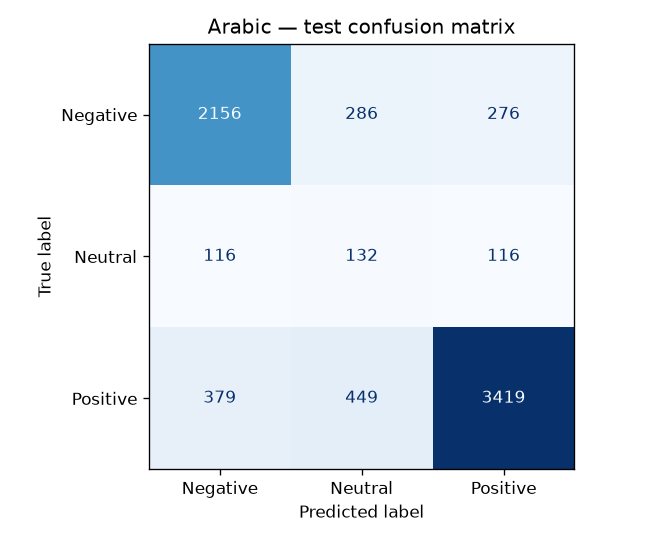

In [9]:
best_row = val_results.iloc[0]
best_model_name, best_feature_name = best_row["Model"], best_row["Features"]
print("validation winner:", best_model_name, "+", best_feature_name)

X_train_os, y_train_os = oversample_neutral(X_train, y_train)
best = build_arabic_pipeline(best_feature_name, best_model_name)
best.fit(X_train_os, y_train_os)
y_pred = best.predict(X_test)
print("\nHeld-out TEST")
print(classification_report(y_test, y_pred, labels=LABELS, digits=4, zero_division=0))
print(pd.Series(scores(y_test, y_pred), name="test"))

cm = confusion_matrix(y_test, y_pred, labels=LABELS)
print("Confusion matrix labels", LABELS)
print(cm)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
from IPython.display import display
ConfusionMatrixDisplay(cm, display_labels=LABELS).plot(cmap="Blues", ax=ax, colorbar=False)
ax.set_title("Arabic — test confusion matrix")
plt.tight_layout()
display(fig)

Held-out test confusion matrix (`Negative`, `Neutral`, `Positive`). Split on unique normalized reviews; train/test overlap **0**. After leak-free selection the winner is Logistic Regression + **character n-grams**.

|  | Pred Negative | Pred Neutral | Pred Positive |
| :--- | ---: | ---: | ---: |
| **True Negative** | 2156 | 286 | 276 |
| **True Neutral** | 116 | 132 | 116 |
| **True Positive** | 379 | 449 | 3419 |

Accuracy **0.7787**. Macro-F1 **0.6221**. Neutral F1 **0.2145**. Conflicting normalized groups dropped: **180** (978 rows). Same-label duplicates dropped: **1720**. Empty after preprocess: **704**.

## Error analysis

In [10]:
tmp = ArabicSentimentModel(best)
for text in (
    "الفيلم مش وحش",
    "مش حلو",
    "المنتج لا يستحق المال",
    "الخدمة ممتازة والتجربة كانت رائعة",
    "الفيلم سيء جدا",
):
    print(f"{tmp.predict(text):10}  {text}")

Negative    الفيلم مش وحش
Positive    مش حلو
Positive    المنتج لا يستحق المال
Positive    الخدمة ممتازة والتجربة كانت رائعة
Negative    الفيلم سيء جدا


## 11. Best Model

In [11]:
print(best)
print(best_row.to_dict())

Pipeline(steps=[('vec',
                 TfidfVectorizer(analyzer='char_wb', max_features=30000,
                                 ngram_range=(3, 5))),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=2000))])
{'Model': 'Logistic Regression', 'Features': 'Character n-grams', 'Accuracy': 0.7854340781170049, 'Precision': 0.6309739606966017, 'Recall': 0.6700611839171039, 'F1': 0.6329711694270528}


## 12. Save Model

In [12]:
path = save_arabic_model(best, ROOT / "models" / "Arabic_model_weights.pkl")
print("saved", path.resolve())

saved /home/abdlrhman/Courses/IEEE SSCS/NLP/Week1/Project1/models/Arabic_model_weights.pkl


## 13. Example Predictions

In [13]:
model = ArabicSentimentModel.load(path)
for text in (
    "الفيلم رائع جدا",
    "الخدمة ممتازة",
    "أنا سعيد جدا بالمنتج",
    "أنا أحب هذا المنتج",
    "الفيلم سيء جدا",
    "الخدمة كانت سيئة",
    "الخدمة سيئة للغاية",
    "المنتج لا يستحق المال",
):
    print(f"{model.predict(text):10}  {text}")

Positive    الفيلم رائع جدا
Positive    الخدمة ممتازة
Positive    أنا سعيد جدا بالمنتج
Positive    أنا أحب هذا المنتج
Negative    الفيلم سيء جدا
Negative    الخدمة كانت سيئة
Negative    الخدمة سيئة للغاية
Positive    المنتج لا يستحق المال
